In [296]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns



In [297]:
df = pd.read_csv("ChargingRecords.csv")
df.head()

,UserID,ChargerID,ChargerCompany,Location,ChargerType,StartDay,StartTime,EndDay,EndTime,StartDatetime,EndDatetime,Duration,Demand
0,0,1,1,hotel,0,15-09-2022,20:54:02,15-09-2022,23:59:13,15-09-2022 20:54,15-09-2022 23:59,185,20.36
1,0,1,1,hotel,0,14-09-2022,20:01:05,14-09-2022,21:31:04,14-09-2022 20:01,14-09-2022 21:31,90,10.19
2,0,1,1,hotel,0,14-09-2022,18:54:30,14-09-2022,19:54:29,14-09-2022 18:54,14-09-2022 19:54,60,6.78
3,0,1,1,hotel,0,29-09-2022,18:32:51,30-09-2022,00:16:42,29-09-2022 18:32,30-09-2022 00:16,344,37.65
4,0,1,1,hotel,0,25-09-2022,19:30:15,26-09-2022,00:30:14,25-09-2022 19:30,26-09-2022 00:30,300,33.81


In [298]:
df.tail()

,UserID,ChargerID,ChargerCompany,Location,ChargerType,StartDay,StartTime,EndDay,EndTime,StartDatetime,EndDatetime,Duration,Demand
72851,2155,2649,0,public institution,0,27-01-2022,09:54:44,27-01-2022,09:58:57,27-01-2022 09:54,27-01-2022 09:58,4,0.50
72852,2379,2670,0,sightseeing,1,31-10-2021,14:52:11,31-10-2021,15:20:28,31-10-2021 14:52,31-10-2021 15:20,28,16.53
72853,2388,2670,0,sightseeing,1,03-10-2021,13:52:14,03-10-2021,14:32:13,03-10-2021 13:52,03-10-2021 14:32,40,12.20
72854,2388,2671,0,company,1,18-11-2021,11:37:44,18-11-2021,11:45:37,18-11-2021 11:37,18-11-2021 11:45,8,3.80
72855,2388,2671,0,company,1,30-10-2021,17:29:02,30-10-2021,17:36:47,30-10-2021 17:29,30-10-2021 17:36,8,3.67


In [299]:
df.shape

(72856, 13)

In [300]:
df.columns

Index(['UserID', 'ChargerID', 'ChargerCompany', 'Location', 'ChargerType',
       'StartDay', 'StartTime', 'EndDay', 'EndTime', 'StartDatetime',
       'EndDatetime', 'Duration', 'Demand'],
      dtype='object')

In [301]:
df.dtypes

UserID              int64
ChargerID           int64
ChargerCompany      int64
Location           object
ChargerType         int64
StartDay           object
StartTime          object
EndDay             object
EndTime            object
StartDatetime      object
EndDatetime        object
Duration            int64
Demand            float64
dtype: object

In [302]:
df.isna().sum()

UserID            0
ChargerID         0
ChargerCompany    0
Location          0
ChargerType       0
StartDay          0
StartTime         0
EndDay            0
EndTime           0
StartDatetime     0
EndDatetime       0
Duration          0
Demand            0
dtype: int64

In [303]:
loc_co=df["Location"].value_counts()
loc_co

Location
public area           14082
apartment             14038
resort                 8854
hotel                  8600
company                7558
public institution     7023
public parking lot     3396
market                 3005
restaurant             2222
camping                1630
sightseeing            1203
golf                   1029
accommodation           187
bus garage               29
Name: count, dtype: int64

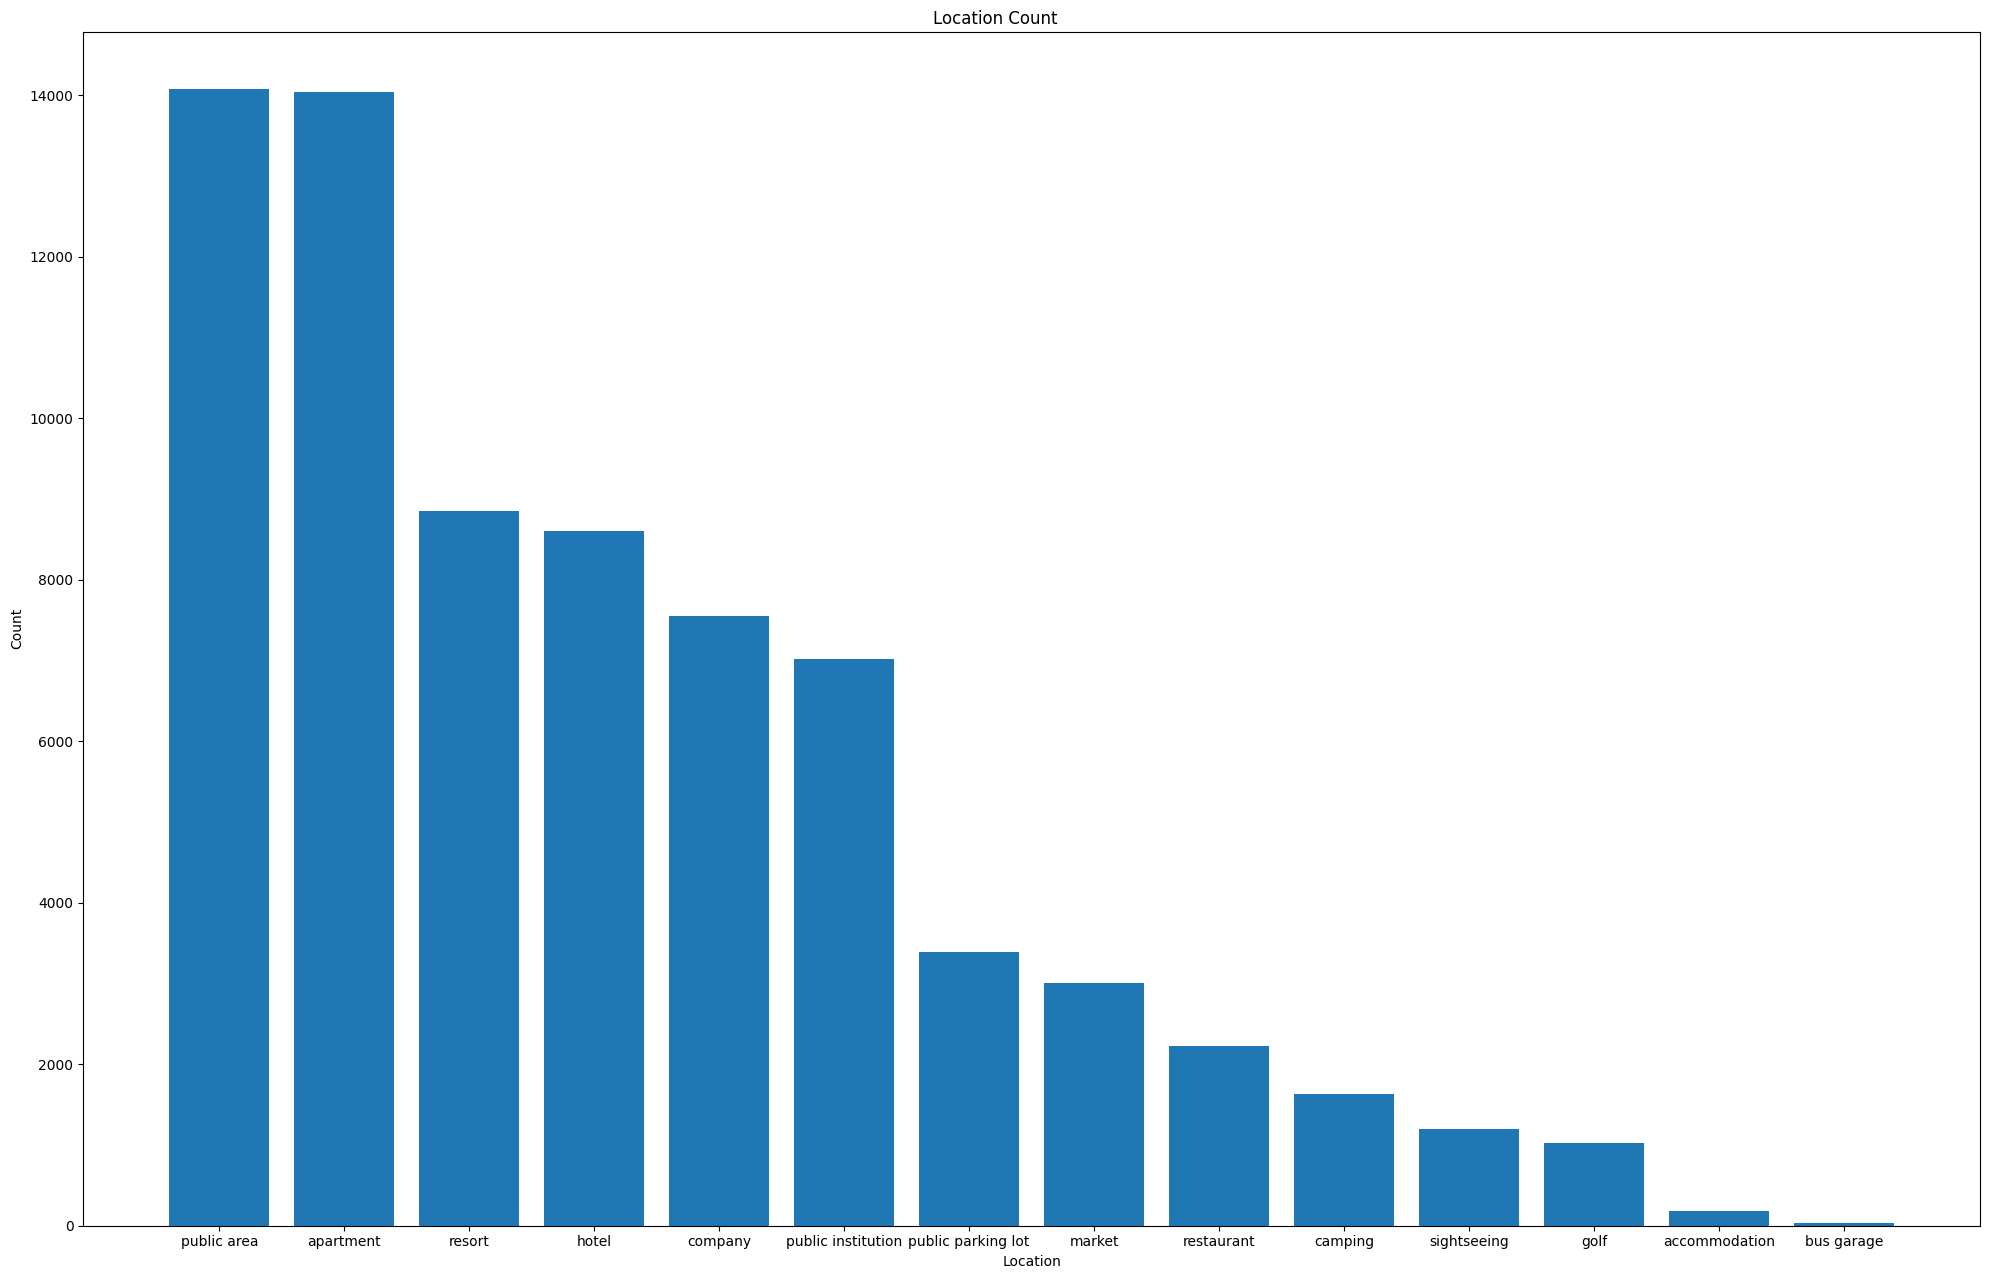

In [304]:
plt.figure(figsize=(20, 13))
plt.bar(loc_co.index,loc_co.values)
plt.suptitle("Location Count")
plt.xlabel("Location")
plt.ylabel("Count")
plt.tight_layout() 

In [305]:
# ==================== DATA CLEANING ====================
df['StartDatetime'] = pd.to_datetime(df['StartDatetime'], format='%d-%m-%Y %H:%M', errors='coerce')
df['EndDatetime']   = pd.to_datetime(df['EndDatetime'], format='%d-%m-%Y %H:%M', errors='coerce')


df['Duration_min'] = (df['EndDatetime'] - df['StartDatetime']).dt.total_seconds() / 60
df = df[df['Duration_min'] > 0].copy()
df = df[df['Demand'] >= 0.01].copy()

In [306]:
# ==================== FEATURE ENGINEERING ====================
df['start_hour']    = df['StartDatetime'].dt.hour
df['start_minute']  = df['StartDatetime'].dt.minute
df['day_of_week']   = df['StartDatetime'].dt.dayofweek
df['is_weekend']    = df['day_of_week'] >= 5
df['month']         = df['StartDatetime'].dt.month
df['quarter']       = df['StartDatetime'].dt.quarter
df['is_peak_hour']  = df['start_hour'].isin([16, 17, 18, 19, 20]).astype(int)

df = df.sort_values(['UserID', 'StartDatetime']).reset_index(drop=True)
df['demand_lag1']   = df.groupby('UserID')['Demand'].shift(1)
df['demand_lag3']   = df.groupby('UserID')['Demand'].shift(3)
df['demand_mean_5'] = df.groupby('UserID')['Demand'].shift(1).rolling(5, min_periods=1).mean()

df['hour_location'] = df['start_hour'].astype(str) + '_' + df['Location'].astype(str)
df['user_location'] = df['UserID'].astype(str) + '_' + df['Location'].astype(str)
df[['demand_lag1', 'demand_lag3', 'demand_mean_5']] = df[['demand_lag1', 'demand_lag3', 'demand_mean_5']].fillna(df['Demand'].median())


df['user_freq'] = df.groupby('UserID')['Demand'].transform('count')
df['location_freq'] = df.groupby('Location')['Demand'].transform('count')
df['charger_user_combo'] = df['UserID'].astype(str) + '_' + df['ChargerType'].astype(str)

df['Location'] = df['Location'].str.strip()
df['UserID'] = df['UserID'].astype(str)
df['ChargerType'] = df['ChargerType'].astype(str)

price_map = {'hotel':0.34,'resort':0.42,'accommodation':0.29,'apartment':0.15,'company':0.00,
             'public institution':0.35,'golf':0.45,'restaurant':0.39,'market':0.42,
             'sightseeing':0.52,'public parking lot':0.48,'public area':0.45,
             'bus garage':0.38,'camping':0.40}
df['Total_Cost_USD'] = (df['Demand'] * df['Location'].map(price_map)).round(2)

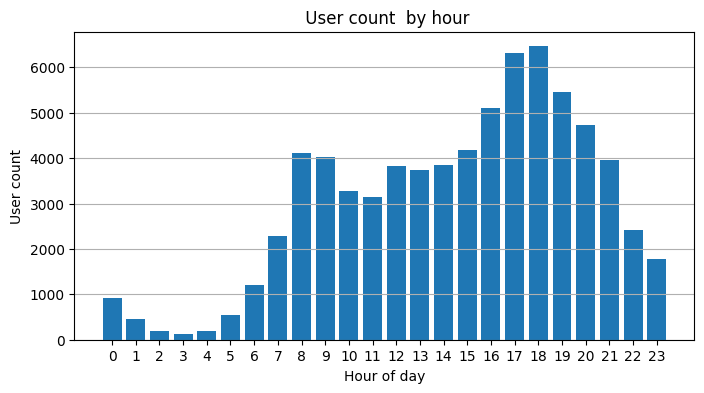

In [307]:
hour_avg = df.groupby("start_hour")["UserID"].count()

plt.figure(figsize=(8,4))
plt.bar(hour_avg.index,hour_avg.values)
plt.xlabel("Hour of day")
plt.ylabel("User count")
plt.title(" User count  by hour")
plt.xticks(range(0,24))
plt.grid(axis='y')


In [308]:
df.drop(['ChargerID','ChargerCompany','StartDay', 'StartTime', 'EndDay', 'EndTime', 'StartDatetime',
       'EndDatetime','Duration'],axis=1,inplace=True)

In [309]:
pd.set_option('display.max_columns', None)
df.head(3)

,UserID,Location,ChargerType,Demand,Duration_min,start_hour,start_minute,day_of_week,is_weekend,month,quarter,is_peak_hour,demand_lag1,demand_lag3,demand_mean_5,hour_location,user_location,user_freq,location_freq,charger_user_combo,Total_Cost_USD
0,0,camping,0,30.17,269.0,19,52,3,False,9,3,1,14.25,14.25,14.250,19_camping,0_camping,31296,1620,0_0,12.07
1,0,public area,0,52.04,458.0,21,8,3,False,9,3,0,30.17,14.25,30.170,21_public area,0_public area,31296,13969,0_0,23.42
2,0,public institution,0,22.30,208.0,21,16,3,False,9,3,0,52.04,14.25,41.105,21_public institution,0_public institution,31296,6978,0_0,7.80


In [310]:
df.dtypes

UserID                 object
Location               object
ChargerType            object
Demand                float64
Duration_min          float64
start_hour              int32
start_minute            int32
day_of_week             int32
is_weekend               bool
month                   int32
quarter                 int32
is_peak_hour            int64
demand_lag1           float64
demand_lag3           float64
demand_mean_5         float64
hour_location          object
user_location          object
user_freq               int64
location_freq           int64
charger_user_combo     object
Total_Cost_USD        float64
dtype: object

In [311]:


x = df.drop(["Demand","Total_Cost_USD"],axis=1)
y_demand = df['Demand']
y_cost = df['Total_Cost_USD']


cat_features = ['UserID', 'Location', 'ChargerType', 'hour_location', 'user_location', 'charger_user_combo']
for col in cat_features:
    x[col] = x[col].astype('category')

user_strat = pd.cut(df['UserID'].astype('int64'), bins=40, labels=False)




In [312]:
from sklearn.model_selection import train_test_split
x_train, x_test, yd_train, yd_test = train_test_split(x, y_demand, test_size=0.2, random_state=41, stratify=user_strat)
x_train_c, x_test_c, yc_train, yc_test = train_test_split(x, y_cost, test_size=0.2, random_state=41, stratify=user_strat)

In [313]:
import lightgbm as lgb

print("\nTraining LightGBM...")
x_train_lgb = x_train.copy()
x_test_lgb  = x_test.copy()


lgb_demand = lgb.train(
    {},                                          
    lgb.Dataset(x_train_lgb, yd_train),              
    valid_sets=[lgb.Dataset(x_test_lgb, yd_test)],
    callbacks=[lgb.early_stopping(200)]         
)
yd_pred=lgb_demand.predict(x_test_lgb)

lgb_cost = lgb.train(
    {},                                         
    lgb.Dataset(x_train_lgb, yc_train),               
    valid_sets=[lgb.Dataset(x_test_lgb, yc_test)],
    callbacks=[lgb.early_stopping(200)]         
)
yc_pred=lgb_cost.predict(x_test_lgb)



Training LightGBM...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002191 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5869
[LightGBM] [Info] Number of data points in the train set: 57847, number of used features: 19
[LightGBM] [Info] Start training from score 17.588497
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's l2: 25.3866
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col

In [314]:
from sklearn.metrics import r2_score

print(f"Demand R²: {r2_score(yd_test, yd_pred)}")
print(f"Cost R²: {r2_score(yc_test, yc_pred)}")



Demand R²: 0.8602366165833342
Cost R²: 0.8952808469756248


In [ ]:
# import joblib
# joblib.dump(lgb_demand, 'lightgbm_demand_model_test.pkl')
# joblib.dump(lgb_cost, 'lightgbm_cost_model_test.pkl')

['lightgbm_cost_model_test.pkl']

In [ ]:
# ==================== HYPERPARAMETER TUNING  ====================


# import optuna



# def lightgbm_objective(trial):
#     params = {
#         'objective': 'regression',
#         'metric': 'rmse',
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
#         'num_leaves': trial.suggest_int('num_leaves', 50, 512),
#         'feature_fraction': trial.suggest_float('feature_fraction', 0.7, 1.0),
#         'bagging_fraction': trial.suggest_float('bagging_fraction', 0.7, 1.0),
#         'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
#         'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 100),
#         'lambda_l1': trial.suggest_float('lambda_l1', 0, 5),
#         'lambda_l2': trial.suggest_float('lambda_l2', 0, 5),
#         'verbosity': -1,
#         'seed': 42
#     }
    
 
#     train_data = lgb.Dataset(x_train, yd_train, categorical_feature=cat_features)
#     val_data = lgb.Dataset(x_test, yd_test, reference=train_data, categorical_feature=cat_features)
    
#     model = lgb.train(params, train_data, valid_sets=[val_data], 
#                       num_boost_round=2000,
#                       callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)])
    
#     preds = model.predict(x_test)
#     return r2_score(yd_test, preds)

# print("\nOptuna Tuning LightGBM ")
# study = optuna.create_study(direction='maximize')
# study.optimize(lightgbm_objective, n_trials=50, show_progress_bar=True)

# best_params = study.best_params
# best_params.update({'objective': 'regression', 'metric': 'rmse', 'verbosity': -1, 'seed': 42})


# print(f"Best Params: {best_params}")

[I 2025-12-07 20:22:03,524] A new study created in memory with name: no-name-c5c737fc-fd63-419a-b9e0-baf7aa0b0f5f



Optuna Tuning LightGBM 


  0%|          | 0/50 [00:00<?, ?it/s]

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[361]	valid_0's rmse: 4.80214


Best trial: 0. Best value: 0.870728:   2%|▏         | 1/50 [00:15<12:15, 15.01s/it]

...

[I 2025-12-07 20:31:49,815] Trial 47 finished with value: 0.872172183607502 and parameters: {'learning_rate': 0.027804441918769098, 'num_leaves': 157, 'feature_fraction': 0.7395886166180776, 'bagging_fraction': 0.8324985292313829, 'bagging_freq': 6, 'min_data_in_leaf': 85, 'lambda_l1': 3.5635600909606517, 'lambda_l2': 2.0066599754681365}. Best is trial 22 with value: 0.8758893993821403.
Training until validation scores don't improve for 200 rounds


Best trial: 22. Best value: 0.875889:  98%|█████████▊| 49/50 [09:53<00:10, 10.83s/it]

Early stopping, best iteration is:
[115]	valid_0's rmse: 4.75575
[I 2025-12-07 20:31:56,695] Trial 48 finished with value: 0.8732135896601548 and parameters: {'learning_rate': 0.07233637872755455, 'num_leaves': 296, 'feature_fraction': 0.9280507323683314, 'bagging_fraction': 0.9116976264212495, 'bagging_freq': 4, 'min_data_in_leaf': 20, 'lambda_l1': 1.362377932891694, 'lambda_l2': 0.005978820757819525}. Best is trial 22 with value: 0.8758893993821403.
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1066]	valid_0's rmse: 4.75437


Best trial: 22. Best value: 0.875889: 100%|██████████| 50/50 [10:14<00:00, 12.30s/it]

[I 2025-12-07 20:32:18,476] Trial 49 finished with value: 0.8732870511726019 and parameters: {'learning_rate': 0.01391463082969008, 'num_leaves': 246, 'feature_fraction': 0.7920774390136065, 'bagging_fraction': 0.8442063726064611, 'bagging_freq': 5, 'min_data_in_leaf': 39, 'lambda_l1': 0.16460679820732693, 'lambda_l2': 4.93069435662359}. Best is trial 22 with value: 0.8758893993821403.
Best Params: {'learning_rate': 0.01138920906773128, 'num_leaves': 201, 'feature_fraction': 0.8773626292406018, 'bagging_fraction': 0.874067712759524, 'bagging_freq': 4, 'min_data_in_leaf': 20, 'lambda_l1': 3.6584057267298142, 'lambda_l2': 1.1001702784970213, 'objective': 'regression', 'metric': 'rmse', 'verbosity': -1, 'seed': 42}


In [ ]:
# best_params={'learning_rate': 0.030501729272587826, 'num_leaves': 150, 'feature_fraction': 0.882195499742748, 'bagging_fraction': 0.8988042068143027, 'bagging_freq': 3, 'min_data_in_leaf': 25, 'lambda_l1': 1.2854024067003156, 'lambda_l2': 2.389078946338046, 'objective': 'regression', 'metric': 'rmse', 'verbosity': -1, 'seed': 42}


best_params={'learning_rate': 0.01138920906773128, 'num_leaves': 201, 'feature_fraction': 0.8773626292406018, 'bagging_fraction': 0.874067712759524, 'bagging_freq': 4, 'min_data_in_leaf': 20, 'lambda_l1': 3.6584057267298142, 'lambda_l2': 1.1001702784970213, 'objective': 'regression', 'metric': 'rmse', 'verbosity': -1, 'seed': 42}

In [ ]:
# ==================== FINAL MODELS ====================
print("\nTraining Final LightGBM Models...")

# Demand model
train_data = lgb.Dataset(x_train, yd_train, categorical_feature=cat_features)
val_data = lgb.Dataset(x_test, yd_test, reference=train_data, categorical_feature=cat_features)
lgb_demand = lgb.train(best_params, train_data, valid_sets=[val_data], 
                       num_boost_round=5000,
                       callbacks=[lgb.early_stopping(200), lgb.log_evaluation(500)])

# Cost model
train_cost_data = lgb.Dataset(x_train, yc_train, categorical_feature=cat_features)
val_cost_data = lgb.Dataset(x_test, yc_test, reference=train_cost_data, categorical_feature=cat_features)
lgb_cost = lgb.train(best_params, train_cost_data, valid_sets=[val_cost_data], 
                     num_boost_round=5000,
                     callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)])


Training Final LightGBM Models...
Training until validation scores don't improve for 200 rounds
[500]	valid_0's rmse: 4.75339
[1000]	valid_0's rmse: 4.70961
[1500]	valid_0's rmse: 4.70671
Early stopping, best iteration is:
[1447]	valid_0's rmse: 4.7053
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1118]	valid_0's rmse: 1.71019


In [ ]:
demand_r2 = r2_score(yd_test, lgb_demand.predict(x_test))
cost_r2 = r2_score(yc_test, lgb_cost.predict(x_test))


print("="*80)
print(f"Demand test R²: {demand_r2}")
print(f"Cost test R²: {cost_r2}")
print("="*80)


Demand test R²: 0.8758893993821403
Cost test R²: 0.9013874091415695


In [ ]:
import joblib
joblib.dump(lgb_demand, 'lightgbm_demand_model1.pkl')
joblib.dump(lgb_cost, 'lightgbm_cost_model1.pkl')


['lightgbm_cost_model1.pkl']